<a href="https://colab.research.google.com/github/xeonqq/FourierFeatureSiren/blob/main/ffn_vs_siren_and_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implicit Neural Functions


## Initialization

In [ ]:
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.autograd import Variable
from PIL import Image, ImageFilter
import mon

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [ ]:
window_size   = 1
down_size     = 256
L    		  = 0.5
lr    	      = 1e-5
losses        = {}
psnrs         = {}
outputs       = {}
ress          = {}
total_steps   = 980
summary_steps = 10
save_images   = True
font_size     = 10
line_width    = 2.0
fig_size      = (5, 4.5)
matplotlib.rc("font", **{
	# "family" : "normal",
	"size"   : font_size
})
plt.rcParams["figure.figsize"]    = [5, 4.5]
plt.rcParams["figure.autolayout"] = True

filename      = "a0952-kme_172"
image_file	  = f"data/zero_linr/{filename}_image.png"
depth_file    = f"data/zero_linr/{filename}_depth.png"
# ref_file      = f"data/zero_linr/{filename}_enhanced.png"
ref_file      = f"data/zero_linr/{filename}_ref.png"
output_dir    = f"run/zero_linr/{filename}"
image_v       = None
ref_v         = None
res_gt        = None
edge          = None

mon.delete_dir(output_dir)
mon.Path(output_dir).mkdir(parents=True, exist_ok=True)

## Misc

In [ ]:
def mse(image1, image2):
	image_array1 = np.array(image1)
	image_array2 = np.array(image2)
	# Calculate the squared difference
	squared_difference = (image_array1 - image_array2) ** 2
	# Calculate the mean squared difference
	return np.mean(squared_difference)


def loss_to_psnr(loss, max=2):
	# return 10 * np.log10(max ** 2 / np.asarray(loss))
	return -10 * np.log10(2.0 * np.asarray(loss))


def laplace(y, x):
	grad = gradient(y, x)
	return divergence(grad, x)


def divergence(y, x):
	div = 0.
	for i in range(y.shape[-1]):
		div += torch.autograd.grad(y[..., i], x, torch.ones_like(y[..., i]), create_graph=True)[0][..., i:i+1]
	return div


def gradient(y, x, grad_outputs=None):
	if grad_outputs is None:
		grad_outputs = torch.ones_like(y)
	grad = torch.autograd.grad(y, [x], grad_outputs=grad_outputs, create_graph=True)[0]
	return grad

In [ ]:
def get_image_tensor():
	image = get_image_color(image_file)
	depth = get_image_gray(depth_file)
	ref   = get_image_color(ref_file)
	return image, depth, ref


def get_image_color(path):
	"""Reads and returns RGB image, (1, 3, H, W)."""
	image = torch.from_numpy(np.array(Image.open(path))).float()
	image = image / torch.max(image)
	image = torch.movedim(image, -1, 0).unsqueeze(0)
	return image


def get_image_gray(path):
	"""Reads and returns RGB image, (1, 1, H, W)."""
	image = torch.from_numpy(np.array(Image.open(path).convert("L"))).float()
	image = image / torch.max(image)
	image = torch.movedim(image, -1, 0).unsqueeze(0).unsqueeze(0)
	return image


def get_coords(H: int, W: int) -> torch.Tensor:
	"""Creates a coordinates grid for INF."""
	coords = np.dstack(np.meshgrid(np.linspace(0, 1, H), np.linspace(0, 1, W)))
	coords = torch.from_numpy(coords).float().cuda()
	return coords


def ff_embedding(image: torch.Tensor, B: torch.Tensor = None) -> torch.Tensor:
	if B is None:
		return image
	else:
		x_proj    = (2. * np.pi * image) @ B.T
		embedding = torch.cat([torch.sin(x_proj), torch.cos(x_proj)], axis=-1)
		return embedding


def get_patches(image: torch.Tensor, kernel_size: int = 1) -> torch.Tensor:
	"""Creates a tensor where the channel contains patch information."""
	kernel = torch.zeros((kernel_size ** 2, 1, kernel_size, kernel_size)).cuda()

	for i in range(kernel_size):
		for j in range(kernel_size):
			kernel[int(torch.sum(kernel).item()), 0, i, j] = 1

	pad 	  = nn.ReflectionPad2d(kernel_size // 2)
	im_padded = pad(image)
	extracted = torch.nn.functional.conv2d(im_padded, kernel, padding=0).squeeze(0)
	return torch.movedim(extracted, 0, -1)


def get_mgrid(side_length: int, dim: int = 2):
	"""Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int
    """
	tensors = tuple(dim * [torch.linspace(-1, 1, steps=side_length)])
	mgrid   = torch.stack(torch.meshgrid(*tensors), dim=-1)
	mgrid   = mgrid.reshape(-1, dim)
	return mgrid


def interpolate_image(image: torch.Tensor, H: int, W: int) -> torch.Tensor:
	"""Reshapes the image based on new resolution."""
	return F.interpolate(image, size=(H, W))


def get_v_component(image_hsv: torch.Tensor) -> torch.Tensor:
	"""Assumes (1, 3, H, W) HSV image."""
	return image_hsv[:, -1].unsqueeze(0)


def replace_v_component(image_hsv: torch.Tensor, v_new: torch.Tensor) -> torch.Tensor:
	"""Replaces the V component of a HSV image (1, 3, H, W)."""
	image_hsv[:, -1] = v_new
	return image_hsv


def rgb2hsv_torch(rgb: torch.Tensor) -> torch.Tensor:
	cmax, cmax_idx = torch.max(rgb, dim=1, keepdim=True)
	cmin  = torch.min(rgb, dim=1, keepdim=True)[0]
	delta = cmax - cmin
	hsv_h = torch.empty_like(rgb[:, 0:1, :, :])
	cmax_idx[delta == 0] = 3
	hsv_h[cmax_idx == 0] = (((rgb[:, 1:2] - rgb[:, 2:3]) / delta) % 6)[cmax_idx == 0]
	hsv_h[cmax_idx == 1] = (((rgb[:, 2:3] - rgb[:, 0:1]) / delta) + 2)[cmax_idx == 1]
	hsv_h[cmax_idx == 2] = (((rgb[:, 0:1] - rgb[:, 1:2]) / delta) + 4)[cmax_idx == 2]
	hsv_h[cmax_idx == 3] = 0.0
	hsv_h /= 6.0
	hsv_s = torch.where(cmax == 0, torch.tensor(0.).type_as(rgb), delta / cmax)
	hsv_v = cmax
	return torch.cat([hsv_h, hsv_s, hsv_v], dim=1)


def hsv2rgb_torch(hsv: torch.Tensor) -> torch.Tensor:
	hsv_h, hsv_s, hsv_l = hsv[:, 0:1], hsv[:, 1:2], hsv[:, 2:3]
	_c  = hsv_l * hsv_s
	_x  = _c * (- torch.abs(hsv_h * 6.0 % 2.0 - 1) + 1.0)
	_m  = hsv_l - _c
	_o  = torch.zeros_like(_c)
	idx = (hsv_h * 6.0).type(torch.uint8)
	idx = (idx % 6).expand(-1, 3, -1, -1)
	rgb = torch.empty_like(hsv)
	rgb[idx == 0] = torch.cat([_c, _x, _o], dim=1)[idx == 0]
	rgb[idx == 1] = torch.cat([_x, _c, _o], dim=1)[idx == 1]
	rgb[idx == 2] = torch.cat([_o, _c, _x], dim=1)[idx == 2]
	rgb[idx == 3] = torch.cat([_o, _x, _c], dim=1)[idx == 3]
	rgb[idx == 4] = torch.cat([_x, _o, _c], dim=1)[idx == 4]
	rgb[idx == 5] = torch.cat([_c, _o, _x], dim=1)[idx == 5]
	rgb += _m
	return rgb


def diff_x(input: torch.Tensor, r: int) -> torch.Tensor:
	assert input.dim() == 4
	left   = input[:, :,         r:2 * r + 1]
	middle = input[:, :, 2 * r + 1:         ] - input[:, :,           :-2 * r - 1]
	right  = input[:, :,        -1:         ] - input[:, :, -2 * r - 1:    -r - 1]
	output = torch.cat([left, middle, right], dim=2)
	return output


def diff_y(input: torch.Tensor, r: int) -> torch.Tensor:
	assert input.dim() == 4
	left   = input[:, :, :,         r:2 * r + 1]
	middle = input[:, :, :, 2 * r + 1:         ] - input[:, :, :,           :-2 * r - 1]
	right  = input[:, :, :,        -1:         ] - input[:, :, :, -2 * r - 1:    -r - 1]
	output = torch.cat([left, middle, right], dim=3)
	return output


class BoxFilter(nn.Module):

	def __init__(self, r: int):
		super().__init__()
		self.r = r

	def forward(self, x):
		assert x.dim() == 4
		return diff_y(diff_x(x.cumsum(dim=2), self.r).cumsum(dim=3), self.r)


class FastGuidedFilter(nn.Module):

	def __init__(self, r: int, eps: float =1e-8):
		super().__init__()
		self.r		   = r
		self.eps 	   = eps
		self.boxfilter = BoxFilter(r)


	def forward(self, lr_x, lr_y, hr_x):
		n_lrx, c_lrx, h_lrx, w_lrx = lr_x.size()
		n_lry, c_lry, h_lry, w_lry = lr_y.size()
		n_hrx, c_hrx, h_hrx, w_hrx = hr_x.size()

		assert n_lrx == n_lry and n_lry == n_hrx
		assert c_lrx == c_hrx and (c_lrx == 1 or c_lrx == c_lry)
		assert h_lrx == h_lry and w_lrx == w_lry
		assert h_lrx > 2*self.r+1 and w_lrx > 2*self.r+1

		## N
		N = self.boxfilter(Variable(lr_x.data.new().resize_((1, 1, h_lrx, w_lrx)).fill_(1.0)))

		## mean_x
		mean_x = self.boxfilter(lr_x) / N
		## mean_y
		mean_y = self.boxfilter(lr_y) / N
		## cov_xy
		cov_xy = self.boxfilter(lr_x * lr_y) / N - mean_x * mean_y
		## var_x
		var_x = self.boxfilter(lr_x * lr_x) / N - mean_x * mean_x

		## A
		A = cov_xy / (var_x + self.eps)
		## b
		b = mean_y - A * mean_x

		## mean_A; mean_b
		mean_A = F.interpolate(A, (h_hrx, w_hrx), mode='bilinear', align_corners=True)
		mean_b = F.interpolate(b, (h_hrx, w_hrx), mode='bilinear', align_corners=True)

		return mean_A*hr_x+mean_b


def filter_up(x_lr: torch.Tensor, y_lr: torch.Tensor, x_hr: torch.Tensor, r: int = 1) -> torch.Tensor:
	"""Applies the guided filter to upscale the predicted image."""
	guided_filter = FastGuidedFilter(r=r)
	y_hr = guided_filter(x_lr, y_lr, x_hr)
	y_hr = torch.clip(y_hr, 0, 1)
	return y_hr

## Model

### Activation Layers

In [ ]:
class SigmoidLayer(nn.Module):

    def __init__(self, in_channels: int, out_channels: int, *args, **kwargs):
        super().__init__()
        self.in_channels = in_channels
        self.linear      = nn.Linear(in_channels, out_channels)
        self.act         = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.linear(x))
        # return self.linear(x)

In [ ]:
class TanhLayer(nn.Module):

    def __init__(self, in_channels: int, out_channels: int, *args, **kwargs):
        super().__init__()
        self.in_channels = in_channels
        self.linear      = nn.Linear(in_channels, out_channels)
        self.act         = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.linear(x))

In [ ]:
class ReLULayer(nn.Module):

	def __init__(self, in_channels: int, out_channels: int, *args, **kwargs):
		super().__init__()
		self.in_channels = in_channels
		self.linear      = nn.Linear(in_channels, out_channels)
		self.act         = nn.ReLU()

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		return self.act(self.linear(x))

In [ ]:
class SineLayer(nn.Module):

	def __init__(
		self,
		in_channels : int,
		out_channels: int,
		omega_0 	: float = 30,
		is_first	: bool  = False,
	):
		super().__init__()
		self.in_channels = in_channels
		self.omega_0     = omega_0
		self.linear      = nn.Linear(in_channels, out_channels)
		self.is_first    = is_first
		self.init_weights()

	def init_weights(self):
		b = 1.0 / self.in_channels if self.is_first else np.sqrt(6.0 / self.in_channels) / self.omega_0
		with torch.no_grad():
			self.linear.weight.uniform_(-b, b)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		return torch.sin(self.omega_0 * self.linear(x))

In [ ]:
class GaussLayer(nn.Module):

    def __init__(
        self,
        in_channels : int,
        out_channels: int,
        scale       : float = 10.0,
        *args, **kwargs
    ):
        super().__init__()
        self.in_channels = in_channels
        self.scale       = scale
        self.linear      = nn.Linear(in_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.exp(-(self.scale * self.linear(x)) ** 2)

In [ ]:
class FINERLayer(nn.Module):

	def __init__(
		self,
		in_channels     : int,
		out_channels    : int,
		omega_0         : float = 30.0,
		first_bias_scale: float = None,
		is_first        : bool  = False,
		scale_req_grad  : bool  = False,
	):
		super().__init__()
		self.omega_0     = omega_0
		self.is_first    = is_first
		self.in_channels = in_channels
		self.linear      = nn.Linear(in_channels, out_channels)

		self.init_weights()
		self.scale_req_grad   = scale_req_grad
		self.first_bias_scale = first_bias_scale
		if self.first_bias_scale is not None:
			self.init_first_bias()

	def init_weights(self):
		with torch.no_grad():
			if self.is_first:
				self.linear.weight.uniform_(-1 / self.in_channels, 1 / self.in_channels)
			else:
				self.linear.weight.uniform_(-np.sqrt(6 / self.in_channels) / self.omega_0,
										 	 np.sqrt(6 / self.in_channels) / self.omega_0)

	def init_first_bias(self):
		with torch.no_grad():
			if self.is_first:
				self.linear.bias.uniform_(-self.first_bias_scale, self.first_bias_scale)

	def generate_scale(self, x: torch.Tensor) -> torch.Tensor:
		if self.scale_req_grad:
			scale = torch.abs(x) + 1
		else:
			with torch.no_grad():
				scale = torch.abs(x) + 1
		return scale

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		linear = self.linear(x)
		scale  = self.generate_scale(linear)
		return torch.sin(self.omega_0 * scale * linear)

In [ ]:
class FINERLayer20(nn.Module):

	def __init__(
		self,
		in_channels     : int,
		out_channels    : int,
		omega_0         : float = 30.0,
		first_bias_scale: float = 20.0,
		is_first        : bool  = False,
		scale_req_grad  : bool  = False,
	):
		super().__init__()
		self.omega_0     = omega_0
		self.is_first    = is_first
		self.in_channels = in_channels
		self.linear      = nn.Linear(in_channels, out_channels)

		self.init_weights()
		self.scale_req_grad   = scale_req_grad
		self.first_bias_scale = first_bias_scale
		if self.first_bias_scale is not None:
			self.init_first_bias()

	def init_weights(self):
		with torch.no_grad():
			if self.is_first:
				self.linear.weight.uniform_(-1 / self.in_channels, 1 / self.in_channels)
			else:
				self.linear.weight.uniform_(-np.sqrt(6 / self.in_channels) / self.omega_0,
											np.sqrt(6 / self.in_channels) / self.omega_0)

	def init_first_bias(self):
		with torch.no_grad():
			if self.is_first:
				self.linear.bias.uniform_(-self.first_bias_scale, self.first_bias_scale)

	def generate_scale(self, x: torch.Tensor) -> torch.Tensor:
		if self.scale_req_grad:
			scale = torch.abs(x) + 1
		else:
			with torch.no_grad():
				scale = torch.abs(x) + 1
		return scale

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		linear = self.linear(x)
		scale  = self.generate_scale(linear)
		return torch.sin(self.omega_0 * scale * linear)

### Define INF module

In [ ]:
class INF1_Patch(nn.Module):

	def __init__(
		self,
		patch_dim   : int   = 1 ** 2,
		hidden_dim  : int   = 256,
		num_layers  : int   = 4,
		add_layer   : int   = 2,
		v_act_layer : Any   = SineLayer,
		use_ff      : bool  = False,
		ff_scale	: float = 10,
		weight_decay: float = None
	):
		super().__init__()
		if use_ff:
			self.register_buffer("B", torch.randn((hidden_dim, patch_dim)) * ff_scale)
			patch_in_channels   = hidden_dim * 2
		else:
			self.B 				= None
			patch_in_channels   = patch_dim

		patch_layers   = [v_act_layer(patch_in_channels, hidden_dim, is_first=True)]
		output_layers  = []

		for _ in range(1, add_layer - 2):
			patch_layers.append(v_act_layer(hidden_dim, hidden_dim))
		patch_layers.append(v_act_layer(hidden_dim, hidden_dim))

		for _ in range(add_layer, num_layers - 1):
			output_layers.append(v_act_layer(hidden_dim, hidden_dim))
		output_layers.append(SigmoidLayer(hidden_dim, 1))

		self.patch_net   = nn.Sequential(*patch_layers)
		self.output_net  = nn.Sequential(*output_layers)

		if not weight_decay:
			weight_decay = [0.1, 0.0001, 0.001]

		self.params  = []
		self.params += [{"params": self.patch_net.parameters(),   "weight_decay": weight_decay[1]}]
		self.params += [{"params": self.output_net.parameters(),  "weight_decay": weight_decay[2]}]

	def forward(self, spatial: torch.Tensor, patch: torch.Tensor) -> torch.Tensor:
		patch = ff_embedding(patch, self.B)
		return self.output_net(self.patch_net(patch))

In [ ]:
class INF1_Spatial(nn.Module):

	def __init__(
		self,
		patch_dim   : int   = 1 ** 2,
		hidden_dim  : int   = 256,
		num_layers  : int   = 4,
		add_layer   : int   = 2,
		s_act_layer : Any   = SineLayer,
		use_ff      : bool  = False,
		ff_scale	: float = 10,
		weight_decay: float = None
	):
		super().__init__()
		if use_ff:
			self.register_buffer("B", torch.randn((hidden_dim, 2)) * ff_scale)
			spatial_in_channels = hidden_dim * 2
		else:
			self.B 				= None
			spatial_in_channels = 2

		spatial_layers = [s_act_layer(spatial_in_channels, hidden_dim, is_first=True)]
		output_layers  = []

		for _ in range(1, add_layer - 2):
			spatial_layers.append(s_act_layer(hidden_dim, hidden_dim))
		spatial_layers.append(s_act_layer(hidden_dim, hidden_dim))

		for _ in range(add_layer, num_layers - 1):
			output_layers.append(s_act_layer(hidden_dim, hidden_dim))
		output_layers.append(SigmoidLayer(hidden_dim, 1))

		self.spatial_net = nn.Sequential(*spatial_layers)
		self.output_net  = nn.Sequential(*output_layers)

		if not weight_decay:
			weight_decay = [0.1, 0.0001, 0.001]

		self.params  = []
		self.params += [{"params": self.spatial_net.parameters(), "weight_decay": weight_decay[0]}]
		self.params += [{"params": self.output_net.parameters(),  "weight_decay": weight_decay[2]}]

	def forward(self, spatial: torch.Tensor, patch: torch.Tensor) -> torch.Tensor:
		spatial = ff_embedding(spatial, self.B)
		return self.output_net(self.spatial_net(spatial))

In [ ]:
class INF2(nn.Module):

	def __init__(
		self,
		patch_dim   : int   = 1 ** 2,
		hidden_dim  : int   = 256,
		num_layers  : int   = 4,
		add_layer   : int   = 2,
		v_act_layer : Any   = SineLayer,
		s_act_layer : Any   = SineLayer,
		use_ff      : bool  = False,
		ff_scale	: float = 10,
		weight_decay: float = None
	):
		super().__init__()
		if use_ff:
			self.register_buffer("B1", torch.randn((hidden_dim, 2)) * ff_scale)
			spatial_in_channels = hidden_dim * 2
			self.register_buffer("B2", torch.randn((hidden_dim, patch_dim)) * ff_scale)
			patch_in_channels   = hidden_dim * 2
		else:
			self.B1 		    = None
			self.B2 		    = None
			spatial_in_channels = 2
			patch_in_channels   = patch_dim

		spatial_layers = [s_act_layer(spatial_in_channels, hidden_dim, is_first=True)]
		patch_layers   = [v_act_layer(patch_in_channels,   hidden_dim, is_first=True)]
		output_layers  = []

		for _ in range(1, add_layer - 2):
			spatial_layers.append(s_act_layer(hidden_dim, hidden_dim))
			patch_layers.append(  v_act_layer(hidden_dim, hidden_dim))
		spatial_layers.append(s_act_layer(hidden_dim, hidden_dim))
		patch_layers.append(  v_act_layer(hidden_dim, hidden_dim))

		output_layers.append(v_act_layer(hidden_dim * 2, hidden_dim))
		for _ in range(add_layer + 1, num_layers - 1):
			output_layers.append(v_act_layer(hidden_dim, hidden_dim))
		output_layers.append(SigmoidLayer(hidden_dim, 1))

		self.patch_net   = nn.Sequential(*patch_layers)
		self.spatial_net = nn.Sequential(*spatial_layers)
		self.output_net  = nn.Sequential(*output_layers)

		if not weight_decay:
			weight_decay = [0.1, 0.0001, 0.001]

		self.params  = []
		self.params += [{"params": self.spatial_net.parameters(), "weight_decay": weight_decay[0]}]
		self.params += [{"params": self.patch_net.parameters(),   "weight_decay": weight_decay[1]}]
		self.params += [{"params": self.output_net.parameters(),  "weight_decay": weight_decay[2]}]

	def forward(self, spatial: torch.Tensor, patch: torch.Tensor) -> torch.Tensor:
		spatial = ff_embedding(spatial, self.B1)
		patch   = ff_embedding(patch,   self.B2)
		return self.output_net(torch.cat((self.spatial_net(spatial), self.patch_net(patch)), -1))

In [ ]:
class INF4(nn.Module):

	def __init__(
		self,
		patch_dim   : int   = 1 ** 2,
		hidden_dim  : int   = 256,
		num_layers  : int   = 4,
		add_layer   : int   = 2,
		v_act_layer : Any   = SineLayer,
		s_act_layer : Any   = SineLayer,
		use_ff      : bool  = False,
		ff_scale	: float = 10,
		weight_decay: float = None
	):
		super().__init__()
		if use_ff:
			self.register_buffer("B1", torch.randn((hidden_dim, 2)) * ff_scale)
			spatial_in_channels = hidden_dim * 2
			self.register_buffer("B2", torch.randn((hidden_dim, patch_dim)) * ff_scale)
			patch_in_channels   = hidden_dim * 2
		else:
			self.B1 		    = None
			self.B2 		    = None
			spatial_in_channels = 2
			patch_in_channels   = patch_dim

		spatial_layers = [s_act_layer(spatial_in_channels, hidden_dim, is_first=True)]
		patch_layers1  = [v_act_layer(patch_in_channels,   hidden_dim, is_first=True)]
		patch_layers2  = [v_act_layer(patch_in_channels,   hidden_dim, is_first=True)]
		patch_layers3  = [v_act_layer(patch_in_channels,   hidden_dim, is_first=True)]
		output_layers  = []

		for _ in range(1, add_layer - 2):
			spatial_layers.append(s_act_layer(hidden_dim, hidden_dim))
			patch_layers1.append( v_act_layer(hidden_dim, hidden_dim))
			patch_layers2.append( v_act_layer(hidden_dim, hidden_dim))
			patch_layers3.append( v_act_layer(hidden_dim, hidden_dim))
		spatial_layers.append(s_act_layer(hidden_dim, hidden_dim))
		patch_layers1.append( v_act_layer(hidden_dim, hidden_dim))
		patch_layers2.append( v_act_layer(hidden_dim, hidden_dim))
		patch_layers3.append( v_act_layer(hidden_dim, hidden_dim))

		output_layers.append(v_act_layer(hidden_dim * 4, hidden_dim))
		for _ in range(add_layer + 1, num_layers - 1):
			output_layers.append(v_act_layer(hidden_dim, hidden_dim))
		output_layers.append(SigmoidLayer(hidden_dim, 1))

		self.patch_net1  = nn.Sequential(*patch_layers1)
		self.patch_net2  = nn.Sequential(*patch_layers2)
		self.patch_net3  = nn.Sequential(*patch_layers3)
		self.spatial_net = nn.Sequential(*spatial_layers)
		self.output_net  = nn.Sequential(*output_layers)

		if not weight_decay:
			weight_decay = [0.1, 0.0001, 0.001]

		self.params  = []
		self.params += [{"params": self.spatial_net.parameters(), "weight_decay": weight_decay[0]}]
		self.params += [{"params": self.patch_net1.parameters(),  "weight_decay": weight_decay[1]}]
		self.params += [{"params": self.patch_net2.parameters(),  "weight_decay": weight_decay[1]}]
		self.params += [{"params": self.patch_net3.parameters(),  "weight_decay": weight_decay[1]}]
		self.params += [{"params": self.output_net.parameters(),  "weight_decay": weight_decay[2]}]

	def forward(self, spatial: torch.Tensor, patch1: torch.Tensor, patch2: torch.Tensor, patch3: torch.Tensor) -> torch.Tensor:
		spatial = ff_embedding(spatial, self.B1)
		patch1  = ff_embedding(patch1,  self.B2)
		patch2  = ff_embedding(patch2,  self.B2)
		patch3  = ff_embedding(patch3,  self.B2)
		return self.output_net(torch.cat((self.patch_net1(patch1), self.patch_net2(patch2), self.patch_net3(patch3), self.spatial_net(spatial)), -1))

## Training Loop

In [ ]:
class L_exp(nn.Module):

	def __init__(self, patch_size, mean_val):
		super().__init__()
		self.pool     = nn.AvgPool2d(patch_size)
		self.mean_val = mean_val

	def forward(self, x):
		mean = self.pool(x) ** 0.5
		d 	 = torch.abs(torch.mean(torch.pow(mean - torch.FloatTensor([self.mean_val] ).cuda(), 2)))
		return d


class L_TV(nn.Module):

	def __init__(self):
		super().__init__()

	def forward(self, x):
		batch_size = x.size()[0]
		h_x 	   = x.size()[2]
		w_x 	   = x.size()[3]
		count_h    = (x.size()[2] - 1) * x.size()[3]
		count_w    = x.size()[2] * (x.size()[3] - 1)
		h_tv 	   = torch.pow((x[:,:,1:,:] - x[:,:,:h_x-1,:]), 2).sum()
		w_tv 	   = torch.pow((x[:,:,:,1:] - x[:,:,:,:w_x-1]), 2).sum()
		return 2 * (h_tv / count_h + w_tv / count_w) / batch_size

In [ ]:
def calculate_psnr(img1: torch.Tensor, img2: torch.Tensor, max_pixel_value: float = 1.0) -> float:
	"""Calculate the Peak Signal-to-Noise Ratio (PSNR) between two images."""
	assert img1.shape == img2.shape, "Input images must have the same dimensions"
	mse  = F.mse_loss(img1, img2, reduction='mean').item()
	if mse == 0:
		return float("inf")  # Identical images
	psnr = 20 * torch.log10(torch.tensor(max_pixel_value)) - 10 * torch.log10(torch.tensor(mse))
	return psnr.item()

In [ ]:
def train(model, total_steps, steps_til_summary, input_type="pvde"):
	model.to(device)
	optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=3e-4)
	l_exp 	  = L_exp(16, L)
	l_tv 	  = L_TV()

    # Input
	image, depth, ref = get_image_tensor()
	image, depth, ref = image.to(device), depth.to(device), ref.to(device)

	coords    = get_coords(down_size, down_size)

	global image_v
	image_hsv = rgb2hsv_torch(image)
	image_v   = get_v_component(image_hsv)
	image_v   = interpolate_image(image_v, down_size, down_size)

	global edge
	edge      = mon.BoundaryAwarePrior(0.05)(depth)
	depth     = interpolate_image(depth, down_size, down_size)
	edge      = interpolate_image(edge,  down_size, down_size)

	global ref_v
	ref_hsv   = rgb2hsv_torch(ref)
	ref_v     = get_v_component(ref_hsv)
	ref_v     = interpolate_image(ref_v, down_size, down_size)

	# Groundtruth Residual
	global res_gt
	illu_gt   = image_v / ref_v
	res_gt    = illu_gt - image_v

	if input_type == "pv":
		patches  = get_patches(image_v, window_size)
	elif input_type == "pd":
		patches  = get_patches(depth, window_size)
	elif input_type == "pe":
		patches  = get_patches(depth, window_size)
	elif input_type == "pvde":
		patches1 = get_patches(image_v, window_size)
		patches2 = get_patches(depth,   window_size)
		patches3 = get_patches(edge,    window_size)
	else:
		patches  = get_patches(image_v, window_size)

    #
	losses  = []
	psnrs   = []
	outputs = []
	refs    = []
	ress    = []
	for step in range(total_steps):
		model.train()
		optimizer.zero_grad()

		if input_type == "pvde":
			illu_res  = model(coords, patches1, patches2, patches3)
		else:
			illu_res  = model(coords, patches)
		illu_res      = illu_res.view(1, 1, down_size, down_size)
		illu          = illu_res + image_v
		image_v_fixed = image_v / (illu + 1e-4)

		loss_spa 	  = torch.mean(torch.abs(torch.pow(illu - image_v, 2)))
		loss_tv  	  = l_tv(illu)
		loss_exp 	  = torch.mean(l_exp(illu))
		loss_sparsity = torch.mean(image_v_fixed)
		loss          = torch.mean(torch.abs(torch.pow(image_v_fixed - ref_v, 2)))
		# loss 		  = loss_spa * 1 + loss_tv * 20 + loss_exp * 9 + loss_sparsity * 5
		psnr 		  = calculate_psnr(image_v_fixed, ref_v)

		losses.append(loss.item())
		psnrs.append(psnr)
		if not step % steps_til_summary or (step == total_steps - 1):
			print("Step %d, Loss %0.6f, PSNR %0.6f" % (step, loss, psnr))
			outputs.append(image_v_fixed.cpu().view(down_size, down_size).detach().numpy())
			refs.append(ref_v.cpu().view(down_size, down_size).detach().numpy())
			ress.append(illu_res.squeeze(0).squeeze(0).cpu().detach().numpy())
		loss.backward()
		optimizer.step()

	# image_v_fixed   = filter_up(image_v_lr, image_v_fixed_lr, image_v)
	# image_hsv_fixed = replace_v_component(image_hsv, image_v_fixed)
	# image_rgb_fixed = hsv2rgb_torch(image_hsv_fixed)
	# image_rgb_fixed = image_rgb_fixed / torch.max(image_rgb_fixed)

	return losses, psnrs, outputs, ress, refs

## Define Models

In [ ]:
siren_temp = INF1_Spatial(patch_dim=window_size**2, s_act_layer=SineLayer)  # f: p -> r

### FINER20

In [ ]:
finer20_p     = INF1_Spatial(patch_dim=window_size**2, s_act_layer=FINERLayer20)  # f: p -> r
finer20_v     =   INF1_Patch(patch_dim=window_size**2, v_act_layer=FINERLayer20)  # f: v -> r
finer20_d     =   INF1_Patch(patch_dim=window_size**2, v_act_layer=FINERLayer20)  # f: d -> r
finer20_e     =   INF1_Patch(patch_dim=window_size**2, v_act_layer=FINERLayer20)  # f: e -> r
finer20_pv    = 		INF2(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20)  # f: pv -> r
finer20_pd    = 		INF2(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20)  # f: pd -> r
finer20_pe    =         INF2(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20)  # f: pe -> r
finer20       =         INF4(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20)  # f: pvde -> r

ff_finer20_p  = INF1_Spatial(patch_dim=window_size**2, s_act_layer=FINERLayer20, use_ff=True)
ff_finer20_v  =   INF1_Patch(patch_dim=window_size**2, v_act_layer=FINERLayer20, use_ff=True)
ff_finer20_d  =   INF1_Patch(patch_dim=window_size**2, v_act_layer=FINERLayer20, use_ff=True)
ff_finer20_e  =   INF1_Patch(patch_dim=window_size**2, v_act_layer=FINERLayer20, use_ff=True)
ff_finer20_pv = 		INF2(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20, use_ff=True)
ff_finer20_pd = 	    INF2(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20, use_ff=True)
ff_finer20_pe =         INF2(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20, use_ff=True)
ff_finer20    =         INF4(patch_dim=window_size**2, v_act_layer=FINERLayer20, s_act_layer=FINERLayer20, use_ff=True)

# print(sum(p.numel() for p in siren_pv.parameters()) / 1e6, "M parameters")
# print(f"total pixels {down_size * down_size / 1e6}")

## Begin Training

In [ ]:
results = train(siren_temp, total_steps, summary_steps, input_type="pv")
outputs["ref"] = results[4]

### FINER20

In [ ]:
losses["ff_finer20"], psnrs["ff_finer20"], outputs["ff_finer20"], ress["ff_finer20"], _ = train(ff_finer20, total_steps, summary_steps, input_type="pvde")

## Visualize

In [ ]:
print("Final Loss:")

#plt.figure(figsize=fig_size)
plt.subplots(figsize=fig_size)
for n in losses:
	plt.plot(losses[n], label=n, linewidth=line_width)
	plt.legend(prop={"size": font_size})
	print(f"{n}: {losses[n][-1]}")
plt.xlabel("Steps")
plt.ylabel("Loss")
# plt.ylim(0.0, 1.0)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend(bbox_to_anchor=(1, 1), loc=1, borderaxespad=0)
plt.savefig(f"{output_dir}/loss_{total_steps}.jpg", dpi=100, bbox_inches="tight")

plt.clf()
#plt.figure(figsize=fig_size)
plt.subplots(figsize=fig_size)
for n in losses:
  plt.plot(losses[n], label=n, linewidth=line_width)
  plt.legend(prop={"size": font_size})
  # print(f"{n}: {losses[n][-1]}")
plt.xlabel("Steps")
plt.ylabel("Loss")
# plt.ylim(0.0, 0.013)
# plt.ylim(0.0, 0.5)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.legend(bbox_to_anchor=(1, 1), loc=1, borderaxespad=0)
# plt.savefig(f"{output_dir}/loss_{total_steps}_small.jpg", dpi=100, bbox_inches="tight")

In [ ]:
# print("Final PSNR:")

#plt.figure(figsize=fig_size)
plt.subplots(figsize=fig_size)
for n in psnrs:
  plt.plot(psnrs[n], label=n, linewidth=line_width)
  plt.legend(prop={"size": font_size})
  # Print best
  max_psnr  = max(psnrs[n])
  max_index = psnrs[n].index(max_psnr)
  print(f"{max_psnr}")
  # print(f"PSNR {n}: {max_psnr}")
  # print(f"PSNR {n}: {psnrs[n][-1]}")
plt.xlabel("Steps")
plt.ylabel("PSNR")
# plt.ylim(24, 28)
plt.ticklabel_format(axis="y", style="plain", scilimits=(0, 0))
# plt.legend(bbox_to_anchor=(1, 1), loc=1, borderaxespad=0)
plt.savefig(f"{output_dir}/psnr_{total_steps}.jpg", dpi=100, bbox_inches="tight")

## Save

In [ ]:
!pip install imageio-ffmpeg
import os, imageio

In [ ]:
# Save out video
if save_images:
    all_preds = np.concatenate([outputs[n] for n in outputs], axis=-1)
    data8     = (255 * (np.clip(all_preds, -1, 1) + 1) / 2).astype(np.uint8)
    f         = os.path.join(f"{output_dir}/training_convergence_{total_steps}.mp4")
    imageio.mimwrite(f, data8, fps=20)
    N = len(outputs)
    # Display video inline
    from IPython.display import HTML
    from base64 import b64encode

    mp4      = open(f, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

In [ ]:
HTML(f'''
<video width=1000 controls autoplay loop>
      <source src="{data_url}" type="video/mp4">
</video>
<table width="1000" cellspacing="0" cellpadding="0">
  <tr>{''.join(N*[f'<td width="{1000//len(outputs)}"></td>'])}</tr>
  <tr>{''.join(N*['<td style="text-align:center">{}</td>'])}</tr>
</table>
'''.format(*list(outputs.keys())))

In [ ]:
plt.imshow(data8[-1], cmap="gray")

In [ ]:
image_v = image_v.squeeze(0).squeeze(0).cpu().detach().numpy()
ref_v   = ref_v.squeeze(0).squeeze(0).cpu().detach().numpy()
res_gt  = res_gt.squeeze(0).squeeze(0).cpu().detach().numpy()
edge    = edge.squeeze(0).squeeze(0).cpu().detach().numpy()

image_v = np.around((image_v / 2 + 0.5) * 255).astype(np.uint8)
ref_v   = np.around((ref_v   / 2 + 0.5) * 255).astype(np.uint8)
res_gt  = np.around((res_gt  / 2 + 0.5) * 255).astype(np.uint8)
edge    = np.around((edge    / 2 + 0.5) * 255).astype(np.uint8)

plt.imshow(ref_v, cmap="gray")
plt.title("groundtruth")

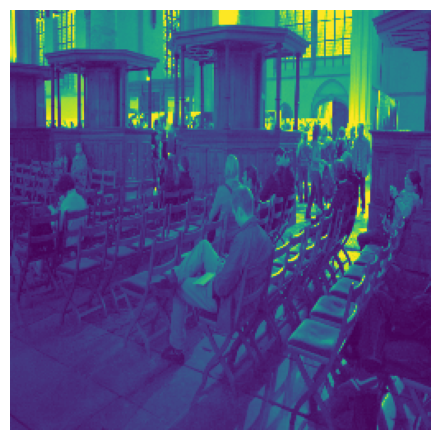

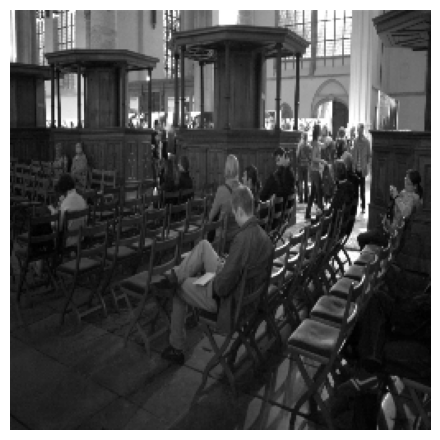

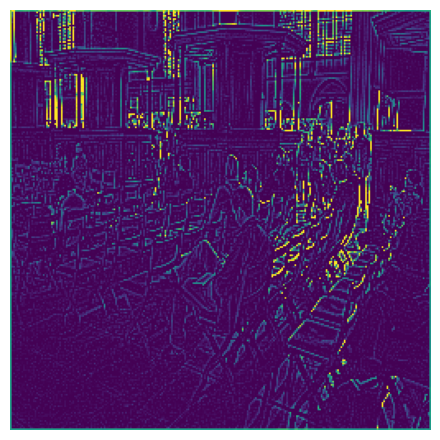

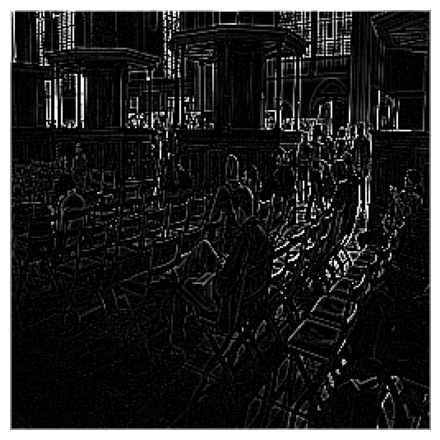

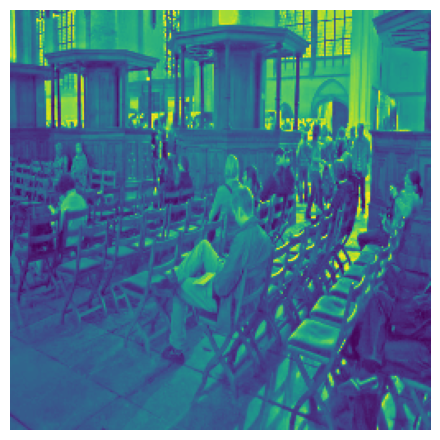

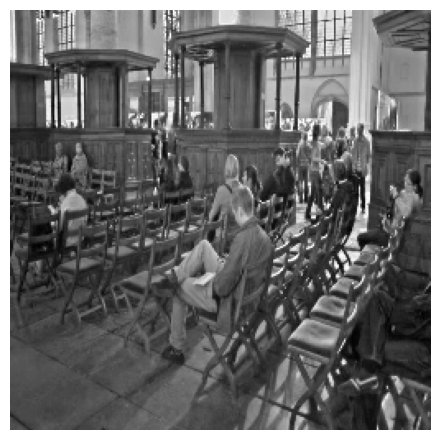

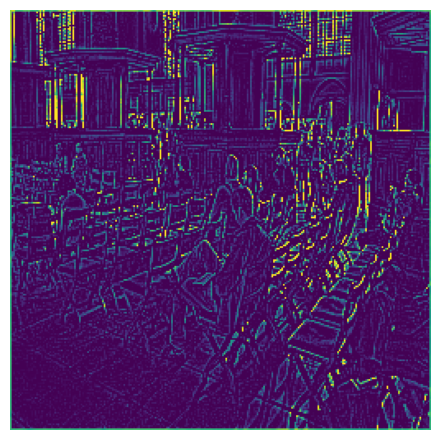

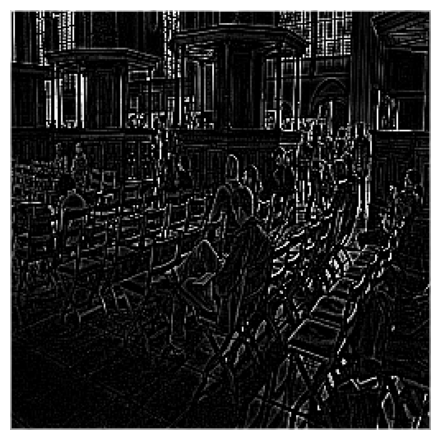

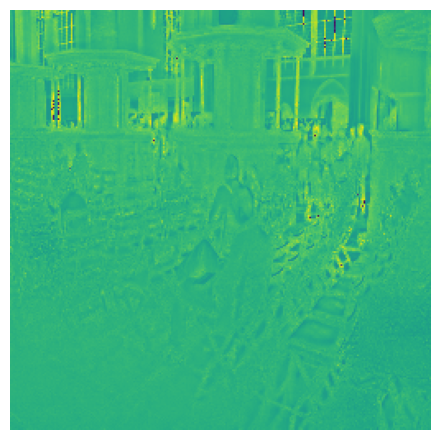

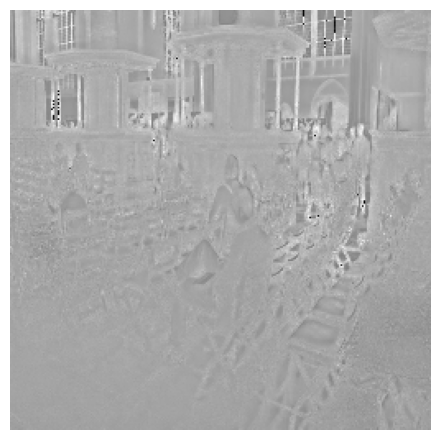

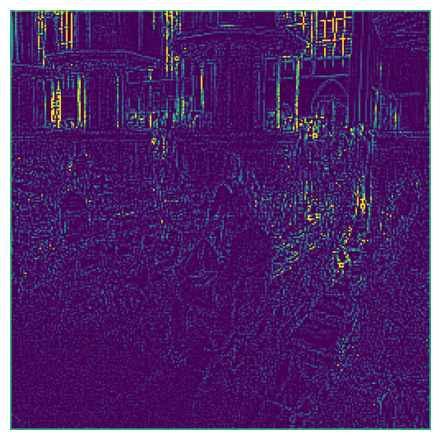

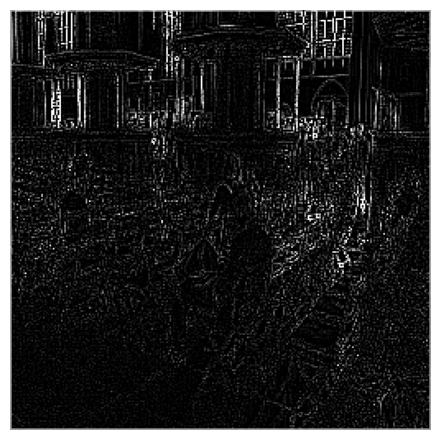

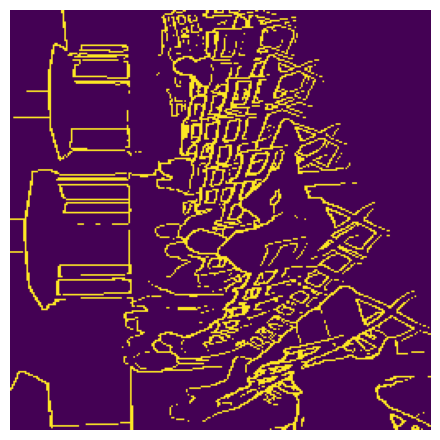

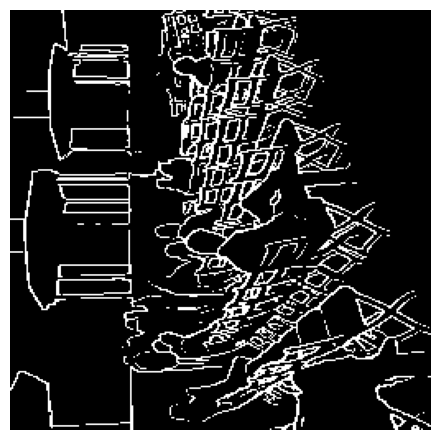

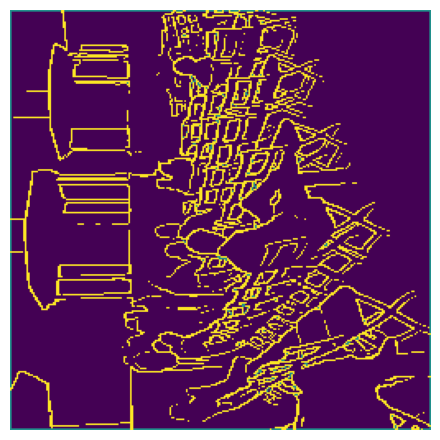

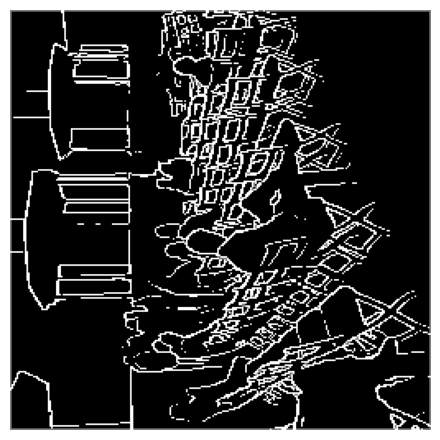

gradient mean squared error:


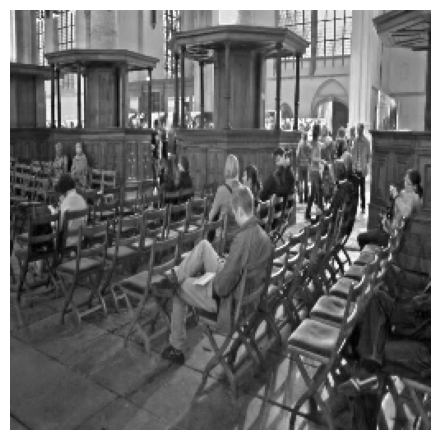

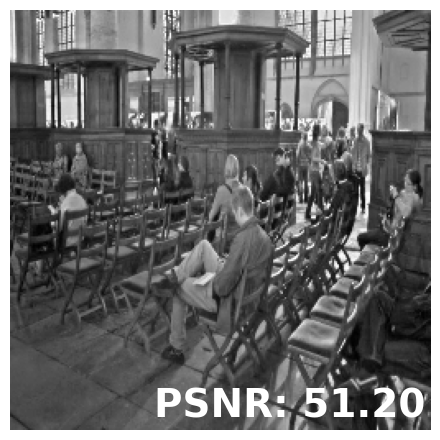

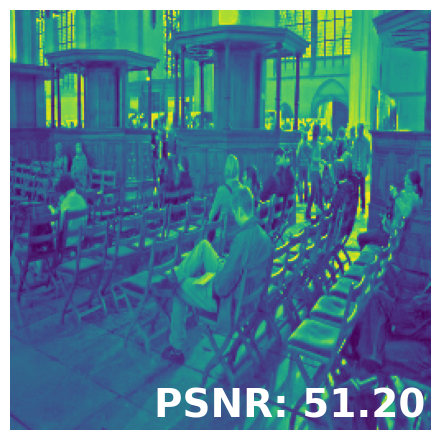

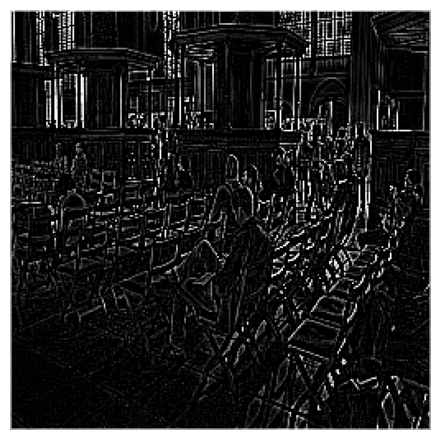

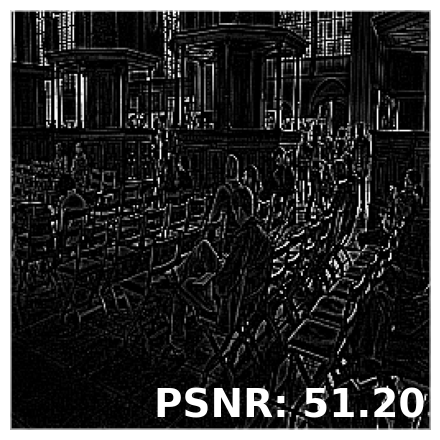

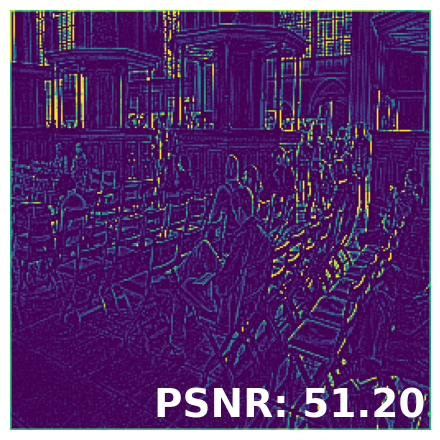

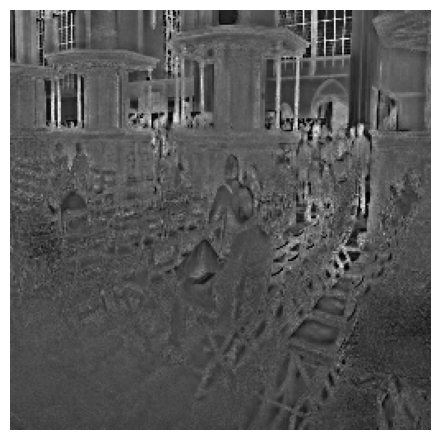

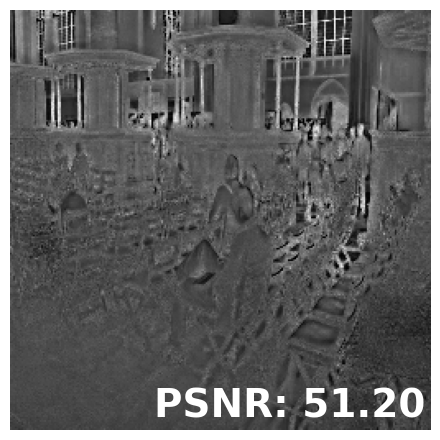

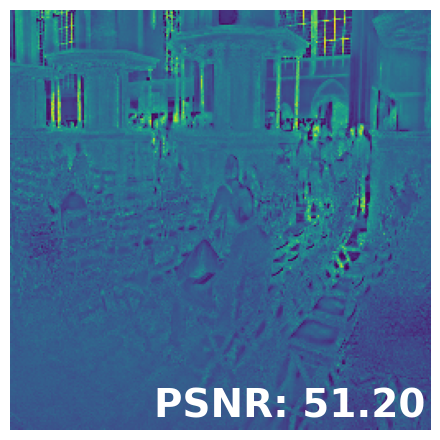

In [600]:
def draw_figure(image, text, save_path, cmap="gray"):
	font = {
		# 'family': 'serif',
		"color" : "white",
		"weight": "bold",
		"size"  : 28,
	}
	fig, axs       = plt.subplots(1, 1)
	dpi            = 100
	left, width    = 0, 1
	bottom, height = 0, 1
	right          = left   + width
	center_x       = left   + width  / 2
	center_y       = bottom + height / 2
	top            = bottom + height
	p              = plt.Rectangle((left, bottom), width, height, linewidth=0, fill=False, facecolor="none", edgecolor=None)
	p.set_transform(axs.transAxes)
	p.set_clip_on(True)

	axs.add_patch(p)
	axs.imshow(image, cmap=cmap)
	axs.title.set_text("")
	axs.text(right - 0.01, bottom + 0.01, text,
			 horizontalalignment = "right",
			 verticalalignment   = "bottom",
			 transform           = axs.transAxes,
			 fontdict            = font)
	axs.set_xticks([])
	axs.set_yticks([])
	axs.set_axis_off()
	plt.show()
	fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0)


if save_images:
	image_pil      = Image.fromarray(image_v)
	image_gradient = image_pil.filter(ImageFilter.FIND_EDGES)

	ref_pil        = Image.fromarray(ref_v)
	ref_gradient   = ref_pil.filter(ImageFilter.FIND_EDGES)

	res_pil        = Image.fromarray(res_gt)
	res_gradient   = res_pil.filter(ImageFilter.FIND_EDGES)

	edge_pil       = Image.fromarray(edge)
	edge_gradient  = edge_pil.filter(ImageFilter.FIND_EDGES)

	# Debugging Purpose
	'''
	gray       = cv2.imread("data/51_ref_dav2_vitl_c.jpg", cv2.IMREAD_GRAYSCALE)
	ksize       = 3
	gX          = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=ksize)
	gY          = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=0, dy=1, ksize=ksize)
	gX          = cv2.convertScaleAbs(gX)
	gY          = cv2.convertScaleAbs(gY)
	combined    = cv2.addWeighted(gX, 0.5, gY, 0.5, 0)
	gt_pil      = Image.fromarray(combined)
	gradient_gt = gt_pil.filter(ImageFilter.FIND_EDGES)
	'''

	image_pil.save(f"{output_dir}/image_v.jpg")
	draw_figure(image_v, "", f"{output_dir}/image_v_color.jpg", cmap="viridis")
	draw_figure(image_v, "", f"{output_dir}/image_v_gray.jpg")
	image_gradient.save(f"{output_dir}/image_v_gradient.jpg")
	draw_figure(image_gradient, "", f"{output_dir}/image_v_gradient_color.jpg", cmap="viridis")
	draw_figure(image_gradient, "", f"{output_dir}/image_v_gradient_gray.jpg")

	ref_pil.save(f"{output_dir}/ref_v.jpg")
	draw_figure(ref_v, "", f"{output_dir}/ref_v_color.jpg", cmap="viridis")
	draw_figure(ref_v, "", f"{output_dir}/ref_v_gray.jpg")
	ref_gradient.save(f"{output_dir}/ref_v_gradient.jpg")
	draw_figure(ref_gradient, "", f"{output_dir}/ref_v_gradient_color.jpg", cmap="viridis")
	draw_figure(ref_gradient, "", f"{output_dir}/ref_v_gradient_gray.jpg")

	res_pil.save(f"{output_dir}/res.jpg")
	draw_figure(res_gt, "", f"{output_dir}/res_color.jpg", cmap="viridis")
	draw_figure(res_gt, "", f"{output_dir}/res_gray.jpg")
	res_gradient.save(f"{output_dir}/res_gradient.jpg")
	draw_figure(res_gradient, "", f"{output_dir}/res_gradient_color.jpg", cmap="viridis")
	draw_figure(res_gradient, "", f"{output_dir}/res_gradient_gray.jpg")

	edge_pil.save(f"{output_dir}/edge.jpg")
	draw_figure(edge, "", f"{output_dir}/edge_color.jpg", cmap="viridis")
	draw_figure(edge, "", f"{output_dir}/edge_gray.jpg")
	edge_gradient.save(f"{output_dir}/edge_gradient.jpg")
	draw_figure(edge_gradient, "", f"{output_dir}/edge_gradient_color.jpg", cmap="viridis")
	draw_figure(edge_gradient, "", f"{output_dir}/edge_gradient_gray.jpg")

	print("gradient mean squared error:")
	for i, n in enumerate(outputs):
		if n in ["ref"]:
			continue
		n_        = n.lower()
		# max_psnr  = max(psnrs[n])
		# max_index = psnrs[n].index(max_psnr)
		# arr       = outputs[n][max_index]
		arr       = outputs[n][-1]
		data8     = (255 * (np.clip(arr, -1, 1) + 1) / 2).astype(np.uint8)
		image     = Image.fromarray(data8)
		gradient  = image.filter(ImageFilter.FIND_EDGES)
		# print(f"{n}: {mse(gradient_gt, gradient)}")

		image.save(f"{output_dir}/{n_}_v_{total_steps}.jpg")
		draw_figure(image, f"", f"{output_dir}/{n_}_v_gray2_{total_steps}.jpg")
		draw_figure(image, f"PSNR: {psnrs[n][-1]:.2f}", f"{output_dir}/{n_}_v_gray_{total_steps}.jpg")
		draw_figure(image, f"PSNR: {psnrs[n][-1]:.2f}", f"{output_dir}/{n_}_v_color_{total_steps}.jpg", cmap="viridis")

		gradient.save(f"{output_dir}/{n_}_v_gradient_{total_steps}.jpg")
		draw_figure(gradient, f"", f"{output_dir}/{n_}_v_gradient_gray2_{total_steps}.jpg")
		draw_figure(gradient, f"PSNR: {psnrs[n][-1]:.2f}", f"{output_dir}/{n_}_v_gradient_gray_{total_steps}.jpg")
		draw_figure(gradient, f"PSNR: {psnrs[n][-1]:.2f}", f"{output_dir}/{n_}_v_gradient_color_{total_steps}.jpg", cmap="viridis")

	for i, n in enumerate(ress):
		if n in ["ref"]:
			continue
		n_        = n.lower()
		# max_psnr  = max(psnrs[n])
		# max_index = psnrs[n].index(max_psnr)
		# arr       = ress[n][max_index]
		arr       = ress[n][-1]
		data8     = (255 * (np.clip(arr, -1, 1) + 1) / 2).astype(np.uint8)
		image     = Image.fromarray(data8)

		image.save(f"{output_dir}/{n_}_r_{total_steps}.jpg")
		draw_figure(image, f"", f"{output_dir}/{n_}_r_gray2_{total_steps}.jpg")
		draw_figure(image, f"PSNR: {psnrs[n][-1]:.2f}", f"{output_dir}/{n_}_r_gray_{total_steps}.jpg")
		draw_figure(image, f"PSNR: {psnrs[n][-1]:.2f}", f"{output_dir}/{n_}_r_color_{total_steps}.jpg", cmap="viridis")